<a href="https://colab.research.google.com/github/MamoMGD1/ML_101/blob/main/notebooks/Section05_Computer_Vision/Chapter02_Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**AUTOENCODERS**

So far we have covered some of the most brilliant ideas built on the foundation of CNNs. Both **AlexNet** and **ResNet** are networks with remarkable power—ResNet even managed to surpass human-level performance on the **ImageNet classification benchmark**.  
That sounds incredible, but if you have noticed, both of these models (and most powerful neural networks) **require large datasets of labeled images** to be trained. They rely on labels to compute loss and improve their predictions through backpropagation.

Earlier in this course, we emphasized a simple but important truth: if we imagine the amount of labeled data in the world as the *topping* of a cake, then the vast amount of **unlabeled data** is the cake itself. Sadly, most of our progress in deep learning still depends only on that small topping, while the massive cake underneath remains largely untouched.  

Think about it: you could easily download a billion images of animals from Google or Pinterest, but they wouldn’t come with reliable labels. File names like `1.jpg` or `image.png` give us nothing. The same applies to text—Wikipedia, books, and articles provide hundreds of billions of sentences, but nobody has labeled them as *positive, negative, question, offensive, polite, sports-related, geography-related, fake news, real news,* and so on.  

Clearly, there is **immense value hidden inside all this unlabeled data**, but we currently lack straightforward ways to use it. We don’t necessarily expect a model to fully “understand” everything from raw unlabeled images, but we can at least hope it discovers useful differences—for example, what makes human faces distinct from zebras.  

This is where a new idea comes in: a family of architectures that do **not depend on labeled data** yet can still learn meaningful representations from the raw inputs themselves.  
These are called **Autoencoders**.

##**Latent Features**  

In machine learning, we often work with **features**—the measurable attributes that describe our data. For example, if we are predicting house prices, we might use the *net area*, *number of rooms*, *number of floors*, *age of the building*, and similar details. These are explicit features, easy to see and record.  

But in reality, many other factors influence the price of a house—factors we may not have measured at all.  
Things like how close the house is to schools, the safety of the neighborhood, how much sunlight enters the living room, or even how satisfied previous tenants were from the house and the neighbors. These hidden, harder-to-measure elements are what we call **latent features**: they exist, they matter, but they are not immediately visible in our dataset.  

The same idea applies to images.  
When we feed an image into a deep CNN, it begins with thousands of raw pixel values. But layer by layer, the network transforms these into a much smaller set of **essential features**—edges, textures, shapes, and eventually abstract concepts like “face,” “wheel,” or “flower.”  
By the time we reach the final layers, the network no longer cares about the individual pixels—it has distilled the input into a compact **latent representation**.  

These latent features are powerful because they capture the **essence of the data**.  
A well-trained CNN can often recognize objects or classify images using just this compressed representation—sometimes reducing tens of thousands of input values into just a few hundred latent ones.  

In short:  
- **Explicit features** are the ones we can directly measure.  
- **Latent features** are the hidden, distilled truths that the model learns to uncover.  

They are not hand-designed by us; they are *discovered* by the network. And in many ways, they hold the deepest meaning of the data.

##**Autoencoders' Structure**

Autoencoders' design is actually brilliant. What makes them so exciting is that they can achieve something we already saw in deep CNN architectures — reducing high-dimensional data into a small, meaningful latent space — but this time without needing any labels.

How do they pull this off? The trick is surprisingly elegant.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C02/autoencoder.png" width="600">
</div>

**Image Credit:** [Original Website](https://www.scaler.com/topics/deep-learning/autoencoders/)

Imagine feeding an image of size $H \times W$ with three channels (RGB) into a network. The first layers convolve filters over it, gradually shrinking the height and width of the feature maps while increasing their depth. As we continue stacking convolution and pooling layers, the network compresses the image further and further until we’re left with a tiny vector that holds all the essence of the original input. This compressed vector sits right in the middle of the network — the **bottleneck** — and it represents the latent features of the image. The part of the network that performs this compression is called the **encoder**, because it “encodes” the image into a compact representation.

But that’s only half the story. After the encoder, we place another network that does the reverse: starting from the bottleneck vector, it upsamples and transforms it step by step until it reconstructs an image of the same shape and depth as the original input. This second half is called the **decoder**, because it “decodes” the compact latent vector back into a full image.

The network is then trained by comparing the reconstructed image ($\hat{x}$) with the original image ($x$). The difference between them — often measured with mean squared error (MSE) — is used as the **loss function**:

$$
Loss = \frac{1}{n} \| x - \hat{x} \|^2
$$

By backpropagating this loss, we are essentially forcing the encoder to learn the most efficient and informative latent features, and the decoder to become skilled at reconstructing images from those features.

After enough training, the encoder becomes intelligent at identifying which aspects of an image matter most for understanding it, while ignoring irrelevant details. The decoder, in turn, learns how to generate realistic outputs from nothing more than the compressed latent vector.

---

This architecture unlocks something incredibly powerful: it reduces the dimensionality of complex data while preserving its most important structures, all without supervision. In other words, the autoencoder learns to “summarize” an image into a small set of numbers and then reconstruct the original image as closely as possible. Unlike traditional compression methods like ZIP or JPEG, which rely on generic algorithms and can still require relatively large storage for high-quality images, autoencoders can achieve a much more compact representation tailored specifically to the data, often using far fewer numbers without losing essential details.


### **Implementation on CIFAR-10**

In the code cells below, our simple autoencoder compresses **CIFAR-10 images (32×32×3)** into three different latent spaces sized **[2, 32, and 256]**, and then reconstructs them back.

- **2 Latent Variables**  
  With only **2 features**, the network barely learns anything beyond **light vs. dark regions**. This resembles the earliest days of a newborn’s vision — where the brain can only make sense of brightness contrasts.

- **32 Latent Variables**  
  At **32 features**, the model begins capturing **shapes, edges, and basic object structures**. It’s no longer just patches of light and dark — we can actually see the outline of some of the objects forming.

- **256 Latent Variables**  
  With **256 features**, the reconstructions retain **colors, textures, and fine details**. At this level, the autoencoder effectively understands almost the full complexity of the images.

---

###**Storage Efficiency**

Let’s compare the storage requirements of CIFAR-10 under different representations:

* **Raw CIFAR-10**

  $$
  60,000 \times 32 \times 32 \times 3 \times 4\text{ bytes} \approx 175.78 \,\text{MB}
  $$

* **Compressed with Autoencoder (256 features per image)**

  $$
  60,000 \times 256 \times 4\text{ bytes} \approx 58.59 \,\text{MB}
  $$

* **Model Parameters**
  \~16.78 MB

**Total cost with model + compressed data ≈ 75.37 MB**

This means our autoencoder **more than halves the storage requirement** while still being able to reconstruct images with high fidelity. Even better:

* Adding **new images** only costs `256 numbers each` (instead of `32×32×3` per image).
* The compression becomes **more efficient as the dataset grows**.

---

But don’t forget — thinking of autoencoders **only** as image compression tools is like buying a smartwatch just to check the time. Sure, it tells time, but that’s the tiniest feature it offers. Most people don’t even wear a smartwatch for timekeeping anymore — they need it for health tracking, notifications, navigation, and countless other functions.

The same goes for autoencoders. Yes, they *can* be used for image compression, but that’s far from their true purpose. Their real value comes from the fact that the encoder learns to **extract meaningful features** from data. Once you have that, you don’t even need the decoder anymore — you can attach a fully connected layer to the encoder and use it as a **custom classifier**, or adapt it for **semantic segmentation**, anomaly detection, and so on.

In other words, autoencoders become a **foundation for transfer learning**, just like we saw in the previous chapter. And the architectures we’ll explore here are only scratching the surface — they represent just a fraction of the ways autoencoders can be designed and applied.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
import torch
import torch.nn as nn
import torch.optim as optim
import torch.functional as F
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torchsummary import summary

In [ ]:
# Reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.enabled = True

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data Preprocessing on CIFAR-10
batch_size = 128

transform_train = transforms.Compose([
    transforms.ToTensor()
])

# Custom worker initialization for DataLoader
def worker_init_fn(worker_id):
    np.random.seed(42 + worker_id)  # Unique seed per worker

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, worker_init_fn=worker_init_fn)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_train)
val_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, worker_init_fn=worker_init_fn)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x
        if self.downsample:
            identity = self.downsample(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity
        out = self.relu(out)
        return out

class Encoder(nn.Module):
    def __init__(self, latent_dim=64, base_channels=32, num_blocks=4, num_poolings=2):
        super().__init__()
        layers = []
        in_ch = 3
        ch = base_channels

        # convolutional blocks
        for i in range(num_blocks):
            layers.append(nn.Conv2d(in_ch, ch, kernel_size=3, stride=1, padding=1))
            layers.append(nn.ReLU(inplace=True))
            in_ch = ch
            ch *= 2
            # apply pooling only for first num_poolings blocks
            if i < num_poolings:
                layers.append(nn.MaxPool2d(2))

        self.conv = nn.Sequential(*layers)

        # get final size after num_poolings (32 -> 32 / 2^num_poolings)
        reduced_size = 32 // (2**num_poolings)
        final_channels = in_ch
        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(final_channels * reduced_size * reduced_size, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        z = self.fc_mu(x)
        return z

class Decoder(nn.Module):
    def __init__(self, latent_dim=64, base_channels=32, num_blocks=4, num_poolings=2):
        super().__init__()
        ch = base_channels * (2**(num_blocks-1))
        reduced_size = 32 // (2**num_poolings)

        self.fc = nn.Linear(latent_dim, ch * reduced_size * reduced_size)
        self.num_blocks = num_blocks
        self.num_poolings = num_poolings

        layers = []
        for i in range(num_blocks):
            layers.append(nn.Conv2d(ch, ch // 2, kernel_size=3, stride=1, padding=1))
            layers.append(nn.ReLU(inplace=True))
            ch //= 2
            # upsample only if it matched an encoder pooling
            if i < num_poolings:
                layers.append(nn.Upsample(scale_factor=2, mode="nearest"))

        layers.append(nn.Conv2d(ch, 3, kernel_size=3, stride=1, padding=1))
        layers.append(nn.Sigmoid())
        self.deconv = nn.Sequential(*layers)

    def forward(self, z):
        reduced_size = 32 // (2**self.num_poolings)
        ch = self.fc.out_features // (reduced_size * reduced_size)
        x = self.fc(z).view(-1, ch, reduced_size, reduced_size)
        return self.deconv(x)

class AutoEncoder(nn.Module):
    def __init__(self, latent_dim=64, base_channels=32, num_blocks=4, num_poolings=2):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = Encoder(latent_dim, base_channels, num_blocks, num_poolings)
        self.decoder = Decoder(latent_dim, base_channels, num_blocks, num_poolings)

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

# Training Function
def train_autoencoder(model, train_loader, val_loader, epochs=20, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []

    pbar = trange(epochs, desc='Preparing to train...')
    for epoch in pbar:
        model.train()
        running_loss = 0.0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            optimizer.zero_grad()
            outputs, _ = model(imgs)
            loss = criterion(outputs, imgs)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation Loss
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(device)
                outputs, _ = model(imgs)
                loss = criterion(outputs, imgs)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Update progress bar
        pbar.set_description(f'Train Loss: {avg_train_loss:.4f} | Validation Loss: {avg_val_loss:.4f}')

    # Plot training and validation loss
    r = np.arange(1, len(train_losses)+1)
    plt.figure(figsize=(6, 4))
    plt.plot(r, train_losses, label="Train Loss", color='red')
    plt.plot(r, val_losses, label="Validation Loss", color='blue')
    plt.grid()
    plt.legend()
    plt.xlabel('Epochs')
    plt.ylabel('Losses')
    plt.title(f"Losses For {model.latent_dim} Latent Vars")
    plt.show()

    return model

100%|██████████| 170M/170M [00:03<00:00, 43.8MB/s]


Train Loss: 0.0355 | Validation Loss: 0.0356: 100%|██████████| 30/30 [05:11<00:00, 10.39s/it]


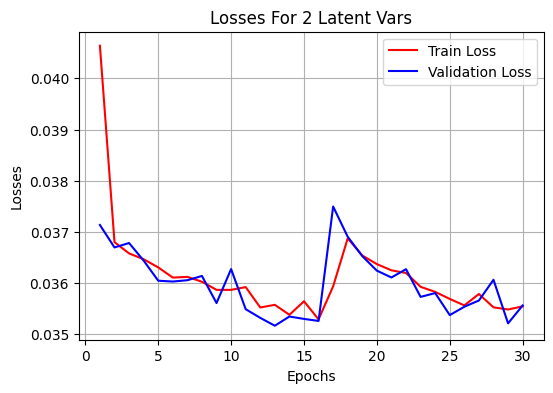

Train Loss: 0.0113 | Validation Loss: 0.0118: 100%|██████████| 30/30 [05:11<00:00, 10.37s/it]


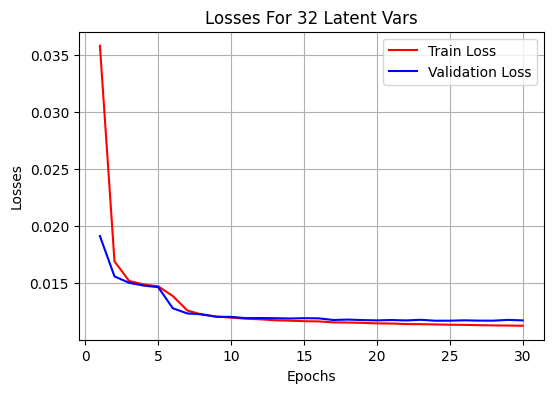

Train Loss: 0.0037 | Validation Loss: 0.0040: 100%|██████████| 30/30 [05:20<00:00, 10.70s/it]


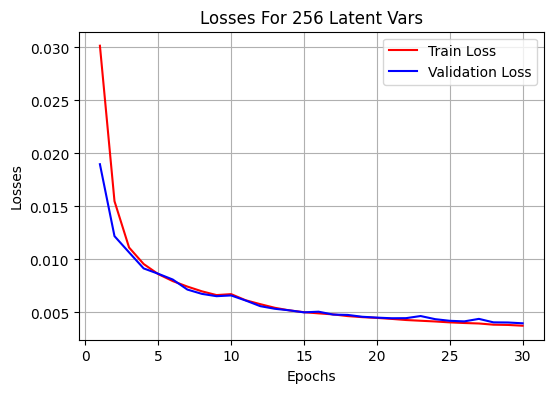

In [ ]:
latent_dims = [2, 32, 256]

# Train a model for different dims
ae_models = []
for dim in latent_dims:
    model = AutoEncoder(latent_dim=dim, base_channels=8, num_blocks=5, num_poolings=2).to(device)
    model = train_autoencoder(model, train_loader, val_loader, epochs=30)
    ae_models.append(model)

In [ ]:
for model in ae_models:
    print(f'\n{"-"*10} Summary of Model With {model.latent_dim} Latent Variables {"-"*11}')
    summary(model, (3, 32, 32))


---------- Summary of Model With 2 Latent Variables -----------
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 32, 32]             224
              ReLU-2            [-1, 8, 32, 32]               0
         MaxPool2d-3            [-1, 8, 16, 16]               0
            Conv2d-4           [-1, 16, 16, 16]           1,168
              ReLU-5           [-1, 16, 16, 16]               0
         MaxPool2d-6             [-1, 16, 8, 8]               0
            Conv2d-7             [-1, 32, 8, 8]           4,640
              ReLU-8             [-1, 32, 8, 8]               0
            Conv2d-9             [-1, 64, 8, 8]          18,496
             ReLU-10             [-1, 64, 8, 8]               0
           Conv2d-11            [-1, 128, 8, 8]          73,856
             ReLU-12            [-1, 128, 8, 8]               0
          Flatten-13                 [

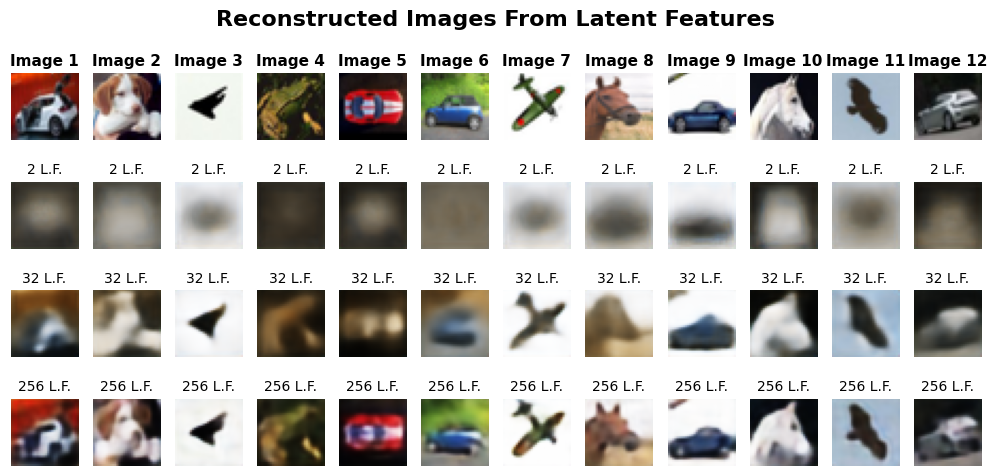

In [ ]:
# Collect all test images into a single tensor using val_loader
all_imgs = []
for imgs, _ in val_loader:
    all_imgs.append(imgs)
all_imgs = torch.cat(all_imgs, dim=0)  # Shape: (10000, 3, 32, 32)

# Pick some indices
idxs = [6, 16, 21, 41, 81, 82, 98, 99, 105, 109, 160, 161]
imgs = all_imgs[idxs].to(device)

# Plot originals and reconstructions
fig, axes = plt.subplots(len(ae_models)+1, len(idxs), figsize=(10, 5))
fig.suptitle("Reconstructed Images From Latent Features", fontsize=16, fontweight='bold')

# Original images
for i in range(len(idxs)):
    axes[0, i].imshow(np.transpose(imgs[i].cpu().numpy(), (1, 2, 0)))
    axes[0, i].set_title(f"Image {i+1}", fontsize=11, fontweight='bold')
    axes[0, i].axis("off")

# Reconstructed images for each model
for row, (model, dim) in enumerate(zip(ae_models, latent_dims), 1):
    model.eval()
    with torch.no_grad():
        recon, _ = model(imgs)
    for i in range(len(idxs)):
        axes[row, i].imshow(np.transpose(recon[i].cpu().numpy(), (1, 2, 0)))
        axes[row, i].set_title(f"{dim} L.F.", fontsize=10)
        axes[row, i].axis("off")

plt.tight_layout()
plt.show()

## **Denoising Autoencoders**

One of the greatest strengths of autoencoders is that **they don’t rely on labels**.
Unlike supervised learning—where the model must output a fixed label like *“cat”* or *“dog”* or *“digits between 0-9”*—here *we* define what the output should look like.

Here’s the core idea:

* We feed an input image \$x\$ to the network.
* The network outputs a reconstruction \$\hat{x}\$.
* The **MSE loss** (mean squared error) looks at the difference between \$x\$ and \$\hat{x}\$,

  $$
  \mathcal{L}(x, \hat{x}) = \frac{1}{n}\sum (x - \hat{x})^2
  $$
* Using **gradient descent or Adam optimizer**, the network’s parameters are updated so that \$\hat{x}\$ gets closer and closer to \$x\$.

In other words: **the job of the loss function + optimizer is to push the autoencoder to transform its input into whatever we told it the output should be.**

Unlike supervised learning, the target \$x\$ doesn’t have to be the exact same input.
We could actually decide *anything* as the reconstruction target:

* If we train with images of **cars** as inputs but set the outputs to **rabbits**, the network will literally learn to turn cars into rabbits (a weird network, but it proves the flexibility!).
* More usefully:

  * If we add **random noise** to images before feeding them in, but keep the target \$x\$ as the clean original, the autoencoder will **learn to remove noise**.
  * That gives us a **denoiser machine**!

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C02/denoising.png" width="700">
</div>  

Because we can control what the “target” \$x\$ is, we can make autoencoders learn all sorts of transformations:

* **Beauty filters** → remove acne, smooth wrinkles, clean blemishes from faces.
* **Cloth repair** → remove stains, wrinkles, or dirt from images of clothes.
* **Object removal** → teach it to erase unwanted objects or people from photos.
* **Watermark removal (Illegal)** → remove text or logos from images.
* **Low-light enhancement** → brighten and clean up images taken at night.
* **Weather cleanup** → remove rain, fog, or snow effects from pictures.

The beauty here is: **it’s the same autoencoder architecture**, only the choice of input/output (and the loss) defines what the network learns to do.

### **Implementation on CIFAR-10**

Here we designed a **Denoising Autoencoder** and applied it to the CIFAR-10 dataset, where the goal was to reconstruct clean images from noisy inputs. As shown in the results, the model successfully learns to remove Gaussian noise while preserving the structure and important features of the objects.

To achieve this, we combined **three types of losses** during training:

1. **L1 Reconstruction Loss**:

   * Ensures that the reconstructed image is globally similar to the original by minimizing pixel-wise differences.
   * High weight ($\alpha$) on this loss makes outputs *less blurry* but can cause the model to ignore finer details.

2. **Perceptual Loss**:

   * Uses pretrained **VGG16 features** to compare high-level representations of the output and the target.
   * Encourages the autoencoder to preserve fine details, textures, and sharper structures, rather than just pixel accuracy.

3. **Gradient Loss**:

   * Preserves **edges and boundaries** by ensuring that gradients (changes in pixel intensity) match between the output and the target.
   * Prevents reconstructions from becoming blurry, especially around sharp edges.

---

#### **Effect of Coefficients**

* By tuning `α`, `β`, and `γ`, we balance **global accuracy**, **visual sharpness**, and **edge clarity**:

  * Large `α` → More faithful reconstruction, but risk of smoothness.
  * Large `β` → More perceptually realistic images, but may sacrifice pixel accuracy.
  * Large `γ` → Sharper edges, less blur, but possible artifacts if too high.

Downloading: "https://download.pytorch.org/models/vgg16_features-amdegroot-88682ab5.pth" to /root/.cache/torch/hub/checkpoints/vgg16_features-amdegroot-88682ab5.pth


100%|██████████| 528M/528M [00:09<00:00, 55.5MB/s]
Train Loss: 1.6592 | Validation Loss: 1.8917: 100%|██████████| 30/30 [10:20<00:00, 20.67s/it]


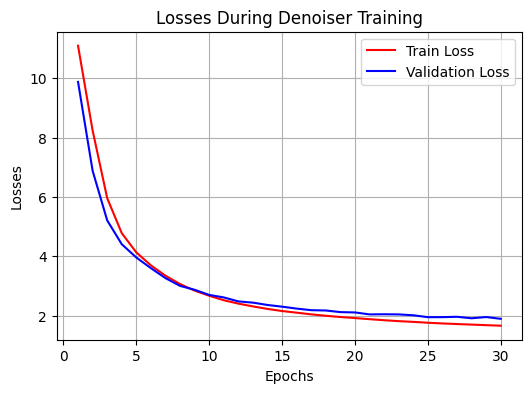

In [ ]:
set_seed()

# Function to add Gaussian noise
def add_noise(imgs, mean=0.0, std=0.1):
    noise = torch.randn_like(imgs) * std + mean
    noisy_imgs = imgs + noise
    noisy_imgs = torch.clamp(noisy_imgs, 0.0, 1.0)
    return noisy_imgs

# Load pretrained VGG for perceptual loss
vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_FEATURES).features[:16].to(device).eval()
for param in vgg.parameters():
    param.requires_grad = False

# Perceptual loss
def perceptual_loss(output, target):
    return F.mse_loss(vgg(output), vgg(target))

# Gradient loss (keeps edges sharp)
def gradient_loss(output, target):
    def gradient(x):
        gx = x[:, :, :, :-1] - x[:, :, :, 1:]
        gy = x[:, :, :-1, :] - x[:, :, 1:, :]
        return gx, gy
    out_gx, out_gy = gradient(output)
    tgt_gx, tgt_gy = gradient(target)
    return F.l1_loss(out_gx, tgt_gx) + F.l1_loss(out_gy, tgt_gy)

# Combined loss function
def combined_loss(output, target, alpha=1.0, beta=0.2, gamma=0.05):
    l1 = F.l1_loss(output, target)          # To ensure overall reconstruction accuracy (make output close to target)
    perc = perceptual_loss(output, target)  # To improve perceptual sharpness & preserve fine details
    grad = gradient_loss(output, target)    # To keep edges crisp & preserve important boundaries
    return alpha*l1 + beta*perc + gamma*grad

# Modified training function for denoiser autoencoder
def train_denoiser_autoencoder(model, train_loader, val_loader, epochs=40, lr=1e-3, noise_std=0.1):
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    pbar = trange(epochs, desc='Preparing to train...')
    for epoch in pbar:
        model.train()
        running_loss = 0.0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            noisy_imgs = add_noise(imgs, std=noise_std)
            optimizer.zero_grad()
            outputs, _ = model(noisy_imgs)

            # Use combined anti-blur loss
            loss = combined_loss(outputs, imgs)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation Loss
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(device)
                noisy_imgs = add_noise(imgs, std=noise_std)
                outputs, _ = model(noisy_imgs)
                loss = combined_loss(outputs, imgs)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Update progress bar
        pbar.set_description(f'Train Loss: {avg_train_loss:.4f} | Validation Loss: {avg_val_loss:.4f}')

    # Plot training and validation loss
    plt.figure(figsize=(6, 4))
    r = np.arange(1, len(train_losses)+1)
    plt.plot(r, train_losses, label="Train Loss", color='red')
    plt.plot(r, val_losses, label="Validation Loss", color='blue')
    plt.grid()
    plt.legend()
    plt.xlabel('Epochs')
    plt.ylabel('Losses')
    plt.title("Losses During Denoiser Training")
    plt.show()

    return model

# Train the Denoiser Model
latent_dim = 256
denoiser = AutoEncoder(latent_dim, base_channels=8, num_blocks=5, num_poolings=2).to(device)
denoiser = train_denoiser_autoencoder(denoiser, train_loader, val_loader, epochs=30)

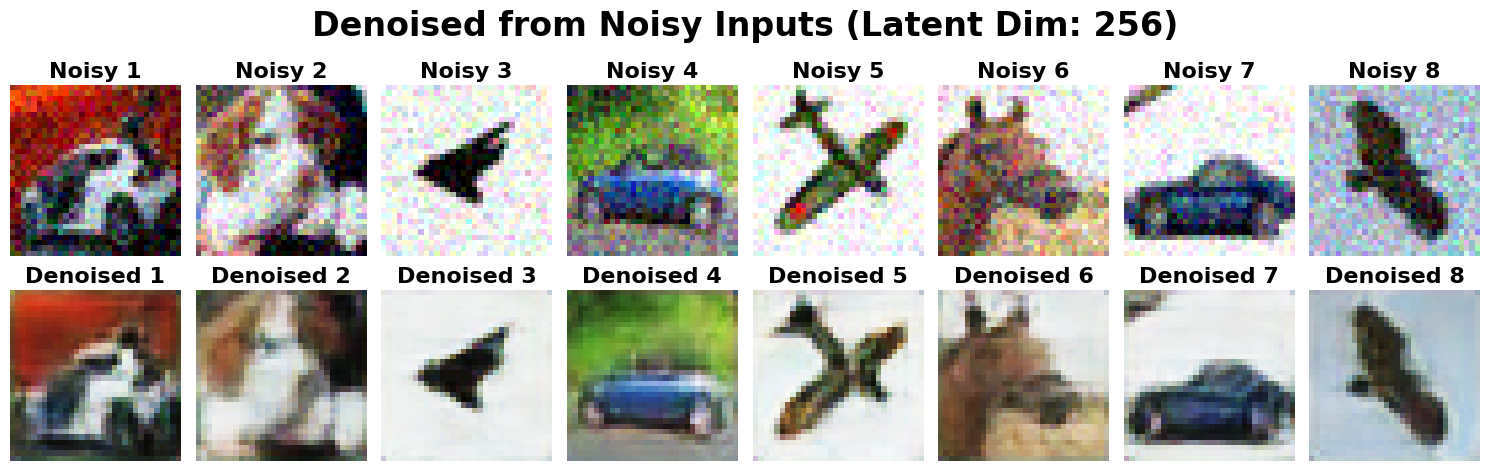

In [ ]:
# Collect all test images into a single tensor using val_loader
all_imgs = []
for imgs, _ in val_loader:
    all_imgs.append(imgs)
all_imgs = torch.cat(all_imgs, dim=0)  # Shape: (10000, 3, 32, 32)

# Pick some indices
idxs = [6, 16, 21, 82, 98, 99, 105, 160]
imgs = all_imgs[idxs].to(device)

# Add noise to the selected images
noisy_imgs = add_noise(imgs)

denoiser.eval()
with torch.no_grad():
    denoised, _ = denoiser(noisy_imgs)

# Plot noisy vs denoised
fig, axes = plt.subplots(2, len(idxs), figsize=(15, 5))
fig.suptitle(f"Denoised from Noisy Inputs (Latent Dim: {latent_dim})", fontsize=24, fontweight='bold')

for i in range(len(idxs)):
    # Noisy
    axes[0, i].imshow(np.transpose(noisy_imgs[i].cpu().numpy(), (1, 2, 0)))
    axes[0, i].set_title(f"Noisy {i+1}", fontsize=16, fontweight='bold')
    axes[0, i].axis("off")

    # Denoised
    axes[1, i].imshow(np.transpose(denoised[i].cpu().numpy(), (1, 2, 0)))
    axes[1, i].set_title(f"Denoised {i+1}", fontsize=16, fontweight='bold')
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

##**Colorizing Autoencoders**

Another fascinating application of autoencoders comes when we **feed grayscale images as input** and expect the **original RGB images as output**.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C02/colorizing.png" width="700">
</div>

The model now has to *imagine* the missing colors:

* If it repeatedly sees images of the sea, it learns that **increasing the blue channel** reduces the loss.
* It picks up on contextual cues: for example, *“when there’s a flat surface at the bottom with dark ship-like objects, that surface is usually blue.”*
* Similarly, it discovers the natural patterns of animals’ fur, grass, sky, flowers, and more.

This way, the autoencoder **learns the colors of objects without any labels at all** — purely by minimizing reconstruction loss.

In the code cells below, you’ll see its implementation on the **CIFAR-10 dataset**.

### **Implementation on CIFAR-10**

In this experiment, we apply a **Colorizer Autoencoder** to the CIFAR-10 dataset.  
The goal is to take grayscale images as input and reconstruct them back into realistic RGB images.  

#### **Key Steps:**
1. **Grayscale Conversion**  
   Each CIFAR-10 image is converted to grayscale by averaging its RGB channels.  
   The grayscale is then expanded back into 3 channels (so the network can handle it the same way as colored inputs).

2. **Loss Functions**  
   To guide training, we use a **combination of pixel-level and perceptual losses**:
   - **MSE Loss** → Ensures pixel values are numerically close.  
   - **L1 Loss** → Encourages sparsity and reduces small residual errors.  
   - **Perceptual Loss (VGG-based)** → Forces reconstructions to look *visually realistic*, not just numerically correct. The perceptual component is crucial—it pushes the model to learn semantic color relationships rather than blindly minimizing pixel differences.

At the end we can see that the model clearly demonstrates it has **learned fundamental color associations** in natural images:
- The **sky and sea** are consistently reconstructed in shades of **blue**.  
- **Grass and vegetation** appear **green**, even when grayscale inputs provide no explicit color clues.  
- **Objects such as cars and animals** regain their typical colors with surprisingly good consistency.  

This shows that the network has captured **statistical regularities of colors in nature**—it’s not just memorizing, but generalizing color patterns based on context.

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 154MB/s]
Train Loss: 0.1471 | Validation Loss: 0.1857: 100%|██████████| 20/20 [12:02<00:00, 36.15s/it]


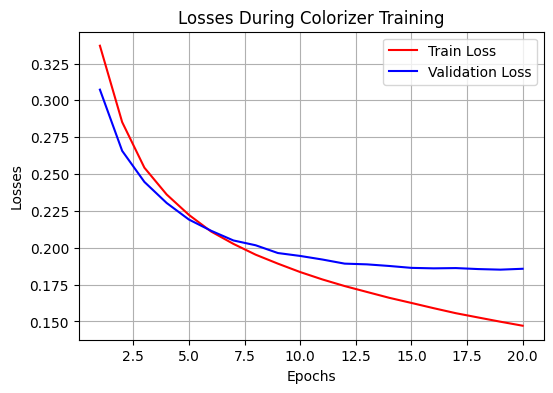

In [ ]:
# Convert RGB to Grayscale
def to_grayscale(imgs):
    # imgs shape: (B, 3, H, W)
    gray = imgs.mean(dim=1, keepdim=True)  # (B, 1, H, W)
    gray = gray.repeat(1, 3, 1, 1)         # expand back to 3 channels
    return gray

# Modified training function with perceptual loss
def train_colorizer_autoencoder(model, train_loader, val_loader, epochs=40, lr=5e-4):
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Pixel-level losses
    mse = nn.MSELoss()
    l1  = nn.L1Loss()

    # Perceptual loss (using pretrained VGG)
    vgg = models.vgg16(weights="IMAGENET1K_V1").features[:16].to(device).eval()
    for param in vgg.parameters():
        param.requires_grad = False

    def perceptual_loss(pred, target):
        pred_features   = vgg(pred)
        target_features = vgg(target)
        return nn.functional.l1_loss(pred_features, target_features)

    train_losses = []
    val_losses   = []

    pbar = trange(epochs, desc='Preparing to train...')
    for epoch in pbar:
        model.train()
        running_loss = 0.0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)                 # RGB (target)
            gray_imgs = to_grayscale(imgs)         # Input: grayscale
            optimizer.zero_grad()

            outputs, _ = model(gray_imgs)

            # Combine losses: pixel + perceptual
            loss_mse = mse(outputs, imgs)
            loss_l1  = l1(outputs, imgs)
            loss_per = perceptual_loss(outputs, imgs)

            # Adjust weights: perceptual encourages sharper, realistic colors
            loss = 0.5 * loss_mse + 0.2 * loss_l1 + 0.3 * loss_per

            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(device)
                gray_imgs = to_grayscale(imgs)
                outputs, _ = model(gray_imgs)

                loss_mse = mse(outputs, imgs)
                loss_l1  = l1(outputs, imgs)
                loss_per = perceptual_loss(outputs, imgs)
                loss = 0.5 * loss_mse + 0.2 * loss_l1 + 0.3 * loss_per

                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Update progress bar
        pbar.set_description(
            f'Train Loss: {avg_train_loss:.4f} | Validation Loss: {avg_val_loss:.4f}'
        )

    # Plot training and validation loss
    plt.figure(figsize=(6, 4))
    r = np.arange(1, len(train_losses)+1)
    plt.plot(r, train_losses, label="Train Loss", color='red')
    plt.plot(r, val_losses, label="Validation Loss", color='blue')
    plt.grid()
    plt.legend()
    plt.xlabel('Epochs')
    plt.ylabel('Losses')
    plt.title("Losses During Colorizer Training")
    plt.show()

    return model

# Train the Colorizer Model
latent_dim = 256
colorizer = AutoEncoder(latent_dim, base_channels=32, num_blocks=5, num_poolings=2).to(device)
colorizer = train_colorizer_autoencoder(colorizer, train_loader, val_loader, epochs=20)

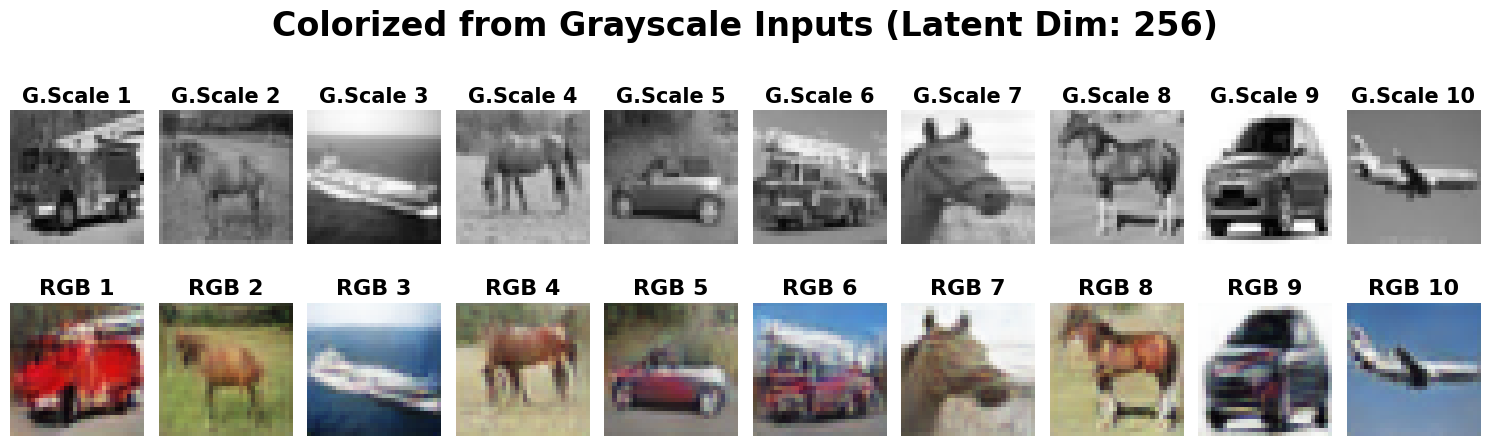

In [ ]:
# Collect all test images into a single tensor using val_loader
all_imgs = []
for imgs, _ in val_loader:
    all_imgs.append(imgs)
all_imgs = torch.cat(all_imgs, dim=0)  # Shape: (10000, 3, 32, 32)

# Pick some indices
idxs = [23, 48, 54, 60, 82, 89, 99, 208, 231, 235]
imgs = all_imgs[idxs].to(device)

# Add noise to the selected images
grayscale_imgs = to_grayscale(imgs)

colorizer.eval()
with torch.no_grad():
    colorized, _ = colorizer(grayscale_imgs)

# Plot noisy vs denoised
fig, axes = plt.subplots(2, len(idxs), figsize=(15, 5))
fig.suptitle(f"Colorized from Grayscale Inputs (Latent Dim: {latent_dim})", fontsize=24, fontweight='bold')

for i in range(len(idxs)):
    # Noisy
    axes[0, i].imshow(np.transpose(grayscale_imgs[i].cpu().numpy(), (1, 2, 0)))
    axes[0, i].set_title(f"G.Scale {i+1}", fontsize=15, fontweight='bold')
    axes[0, i].axis("off")

    # Denoised
    axes[1, i].imshow(np.transpose(colorized[i].cpu().numpy(), (1, 2, 0)))
    axes[1, i].set_title(f"RGB {i+1}", fontsize=16, fontweight='bold')
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

##**Variational Autoencoders**

Earlier, we emphasized how valuable the **encoder** piece of autoencoders is: it learns to extract latent features, reduce dimensions, and capture the essence of images. We even said that sometimes you don’t need the decoder at all — you can throw it away and replace it with a classifier or use the encoder for compression.

That’s true. But if you thought the **decoder** was less important, you’re absolutely wrong.
In fact, the decoder is the **powerhouse behind what we call Generative AI today**.

**Think of it this way:**

* Suppose we train an autoencoder on thousands of human faces.
* Now, if we throw the encoder away and keep only the decoder, what do we have?
* We suddenly own a network that takes a **latent vector** (just an array of numbers) and produces a **realistic human face**.
* These faces don’t even exist in reality — the decoder generates them entirely on its own.

And this doesn’t stop with images:

* If the autoencoder was trained on some text (e.g. stories), the decoder learns how to transform a latent vector into a **coherent text the same as its training text**.
* By providing the right input embedding, the decoder can write tales that never appeared in the training data, all by its own.

**This is the magic of the decoder.**
It’s not just a mirror that reconstructs data — it’s a creative engine, capable of generating **faces, images, texts, and worlds that never existed before.**

### **Variational Autoencoders (VAE) on Faces**

Unlike a standard autoencoder that only learns a compressed latent representation, a **Variational Autoencoder (VAE)** introduces a probabilistic twist:  

- Instead of mapping each input to a single point in latent space, the encoder outputs a **distribution** (mean $\mu$ and variance $\sigma^2$).
- During training, we sample from this distribution using the **reparameterization trick** so gradients can still flow.
- A **KL-divergence penalty** is added to the loss, encouraging the latent space to be as close as possible to a **standard normal distribution**.

This has a very important consequence: if the latent space really follows a normal distribution, then after training we can **sample random vectors from a Gaussian distribution** and pass them to the decoder.  
The decoder should then generate entirely new, realistic-looking faces—even ones that were never in the dataset.

#### **Loss Function**
The VAE optimizes two terms:
- **Reconstruction Loss** → Ensures the generated image looks like the input.  
- **KL Divergence Loss** → Pushes the latent distribution toward a unit Gaussian, which allows random sampling at generation time.

Then we generate faces by feeding **random samples from a normal distribution** into the decoder.  
Even though the inputs were pure noise, the decoder produces **coherent human-like faces**.  
They are still too far from real images of human faces and are quite blurry (a common limitation of VAEs), but the model clearly understands:  
- **Skin tones**,  
- **Facial structures**,  
- **Hair regions**,  
- And other high-level semantic features.  

This experiment demonstrates how VAEs move us from simple *reconstruction* (autoencoders)  
to actual **generative modeling**, where the network can imagine new examples that fit the learned data distribution.

In [ ]:
import kagglehub
from torchvision.datasets import ImageFolder

# Download latest version
path = kagglehub.dataset_download("ashwingupta3012/human-faces")

print("Path to faces dataset files:", path)

Using Colab cache for faster access to the 'human-faces' dataset.
Path to faces dataset files: /kaggle/input/human-faces


Epoch 30 | Train Loss 182.6158 | Val Loss 195.2926: 100%|██████████| 30/30 [1:10:09<00:00, 140.33s/it]


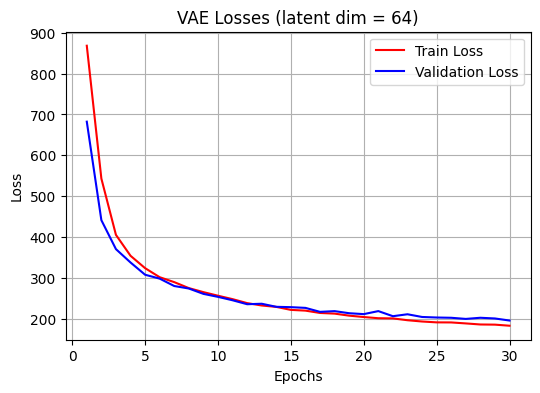

In [ ]:
set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((64, 64)),   # upscale to 64x64
    transforms.Lambda(lambda img: img.convert("RGB")),  # ensure RGB (remove transparency),
    transforms.ToTensor()
])

# Load full dataset
dataset = ImageFolder(root=path, transform=transform)

# Split into train and validation sets (80% train, 20% val)
val_ratio = 0.2
train_size = int((1 - val_ratio) * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, worker_init_fn=worker_init_fn)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2, worker_init_fn=worker_init_fn)

# VAE Model
class Encoder(nn.Module):
    def __init__(self, latent_dim=128, base_channels=32, num_blocks=4):
        super().__init__()
        layers = []
        in_ch = 3
        ch = base_channels
        for i in range(num_blocks):
            layers.append(nn.Conv2d(in_ch, ch, 4, stride=2, padding=1))
            layers.append(nn.ReLU(inplace=True))
            in_ch = ch
            ch *= 2
        self.conv = nn.Sequential(*layers)

        # compute output size dynamically
        dummy = torch.zeros(1, 3, 64, 64)
        out = self.conv(dummy)
        flat_dim = out.numel()

        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

class Decoder(nn.Module):
    def __init__(self, latent_dim=128, base_channels=32, num_blocks=4):
        super().__init__()
        ch = base_channels * (2**(num_blocks-1))
        self.init_channels = ch
        self.init_spatial = 64 // (2**num_blocks)  # should be 4 if input 64
        self.fc = nn.Linear(latent_dim, ch * self.init_spatial * self.init_spatial)

        layers = []
        for i in range(num_blocks-1):
            layers.append(nn.ConvTranspose2d(ch, ch//2, 4, stride=2, padding=1))
            layers.append(nn.ReLU(inplace=True))
            ch //= 2
        layers.append(nn.ConvTranspose2d(ch, 3, 4, stride=2, padding=1))
        layers.append(nn.Sigmoid())
        self.deconv = nn.Sequential(*layers)

    def forward(self, z):
        x = self.fc(z).view(-1, self.init_channels, self.init_spatial, self.init_spatial)
        return self.deconv(x)

class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

# Loss Function
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction="sum") / x.size(0)
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + kl_div, recon_loss, kl_div

# Training Loop
def train_vae(model, train_loader, val_loader, epochs=20, lr=2e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    pbar = trange(epochs, desc="Training VAE...")
    for epoch in pbar:
        # Training
        model.train()
        running_loss = 0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model(imgs)
            loss, recon_loss, kl = vae_loss(recon, imgs, mu, logvar)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(device)
                recon, mu, logvar = model(imgs)
                loss, recon_loss, kl = vae_loss(recon, imgs, mu, logvar)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Progress bar
        pbar.set_description(
            f"Epoch {epoch+1} | Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f}"
        )

    # Plot
    r = np.arange(1, epochs+1)
    plt.figure(figsize=(6, 4))
    plt.plot(r, train_losses, label="Train Loss", color="red")
    plt.plot(r, val_losses, label="Validation Loss", color="blue")
    plt.grid()
    plt.legend()
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"VAE Losses (latent dim = {model.latent_dim})")
    plt.show()

    return model

# Run Training Without Warnings
import warnings
warnings.filterwarnings("ignore", message="Palette images with Transparency*")

latent_dim = 64
vae = VAE(latent_dim).to(device)
vae = train_vae(vae, train_loader, val_loader, epochs=30)

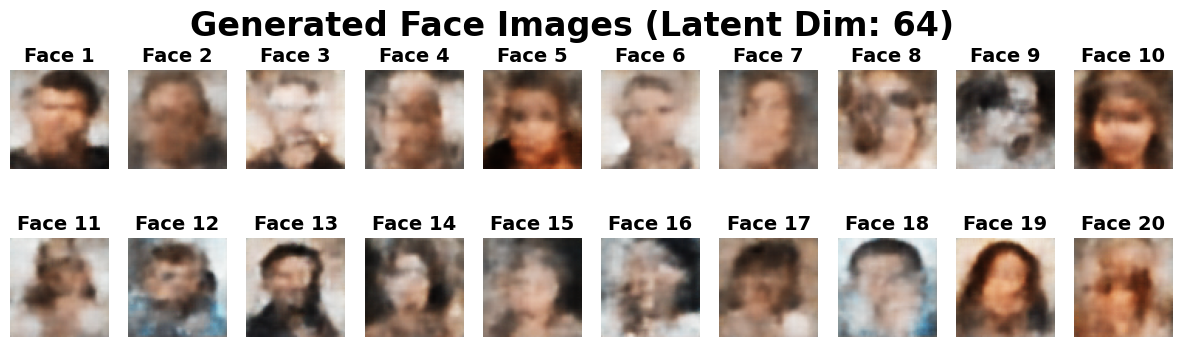

In [ ]:
set_seed()

# Generate Faces
vae.eval()
with torch.no_grad():
    z = torch.randn(20, latent_dim).to(device)
    samples = vae.decoder(z).cpu()

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
fig.suptitle(f"Generated Face Images (Latent Dim: {latent_dim})", fontsize=24, fontweight='bold')

axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.imshow(np.transpose(samples[i].numpy(), (1,2,0)))
    ax.axis("off")
    ax.set_title(f'Face {i+1}', fontweight='bold', fontsize='14')
plt.show()

## **Closing This Chapter**

This chapter was more than just another step forward—it was a turning point.  
With autoencoders, we didn’t just compress and reconstruct data—we learned how to **extract meaning**, **discover structure**, and even **generate new realities**.  

We saw how a simple idea (encode → decode) can unfold into a family of **beautifully creative architectures**:  
- **Basic Autoencoders** that capture the essence of data,  
- **Denoising Autoencoders** that restore clarity from noise,  
- **Variational Autoencoders** that bring imagination into the equation by turning randomness into coherence.  

Each of these showed us that machine learning is not only about accuracy or efficiency—it’s about teaching models to **see patterns, clean them, and reimagine them** in ways that echo the creativity of human thought.  
This chapter was a glimpse into the heart of generative AI, and one of the most beautiful ideas we’ve encountered so far.  

---

### **What’s Next?**

> **Natural Language Processing**

In the next part of our journey, we leave the world of images and step into the world of **language**.  
Just as autoencoders helped us compress, denoise, and generate visual information, Natural Language Processing (NLP) will open the door to understanding, processing, and even generating **human language**.  
We’ll explore how machines can not only see—but also **read, listen, and speak**.